In [2]:
import json
from collections import defaultdict

In [4]:

# Load data
with open('/home/as5606/Datasets/cholec_formatted_data/cholec80_llava_train.json', 'r') as f:
    data = json.load(f)

In [ ]:
# Load data
with open('/home/as5606/Datasets/cholec_formatted_data/cholec80_llava_train.json', 'r') as f:
    data = json.load(f)

binary_yesno_questions = []
non_binary_questions = []

for item in data:
    question = item['conversations'][0]['value'].replace('\n<image>', '').strip()
    
    if question.lower().startswith('is'):
        binary_yesno_questions.append(question)
    else:
        non_binary_questions.append(question)

In [25]:
len(binary_yesno_questions)

26928

In [1]:
import json
import random
import matplotlib.pyplot as plt
from PIL import Image

# Load dataset
with open('/home/as5606/Datasets/cholec_formatted_data/cholec80_llava_train.json', 'r') as f:
    data = json.load(f)

# Get 3 random samples
samples = random.sample(data, 3)

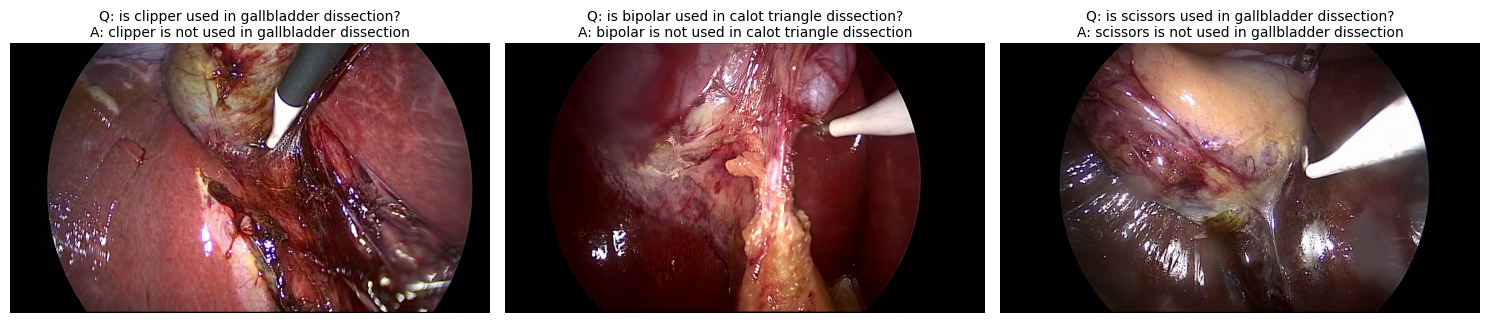

In [2]:
# Display images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (ax, sample) in enumerate(zip(axes, samples)):
    image_path = sample['image']
    question = sample['conversations'][0]['value'].replace('\n<image>', '')
    answer = sample['conversations'][1]['value']
    
    # Load and display image
    img = Image.open(image_path)
    ax.imshow(img)
    ax.set_title(f"Q: {question}\nA: {answer}", fontsize=10, wrap=True)
    ax.axis('off')

plt.tight_layout()
plt.show()

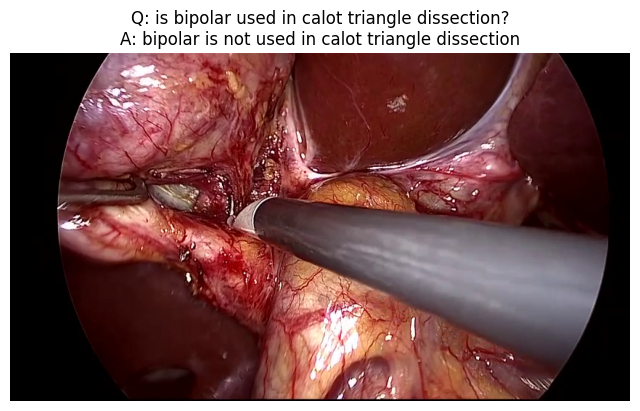

In [4]:
import json
import random
import matplotlib.pyplot as plt
from PIL import Image

# Load dataset
with open('/home/as5606/Datasets/cholec_formatted_data/cholec80_llava_train.json', 'r') as f:
    data = json.load(f)

# Get 1 random sample
sample = random.choice(data)

image_path = sample['image']
question = sample['conversations'][0]['value'].replace('\n<image>', '')
answer = sample['conversations'][1]['value']

# Display image
img = Image.open(image_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Q: {question}\nA: {answer}", fontsize=12)
plt.axis('off')
plt.show()


In [1]:
import json

# Load test dataset
with open('/home/as5606/Datasets/cholec_formatted_data/cholec80_llava_test.json', 'r') as f:
    data = json.load(f)

# Count answers with 'is used'
count_is_used = 0
count_is_not_used = 0

for item in data:
    answer = item['conversations'][1]['value'].lower()
    
    if 'is used' in answer and 'is not used' not in answer:
        count_is_used += 1
    elif 'is not used' in answer:
        count_is_not_used += 1

# Print results
print(f"Total samples: {len(data)}")
print(f"'is used' answers: {count_is_used}")
print(f"'is not used' answers: {count_is_not_used}")
print(f"Other answers: {len(data) - count_is_used - count_is_not_used}")


Total samples: 7652
'is used' answers: 1402
'is not used' answers: 5303
Other answers: 947
